# CSCI E-89: Homework 4

Paul Schwartzberg

## Problem 1: recognise handwritten digits

Adapted from the course notebook `1_pytorch_basic_cnn_digits.ipynb`. We replace scikit-learn's 8 x 8 digit images with MNIST images from torchvision. Each MNIST image has 28 x 28 pixels.

**Progress:** load and inspect the data. Training, evaluation and inference on my own handwriting will follow.

### 1. Set up the environment

Use the `cscie89` kernel. The printed Python path lets us check that the notebook uses the intended environment. A convolutional neural network (CNN) learns image features through filters whose weights change during training.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import datasets, transforms

# Fixed seeds make later splits and model initialisation more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python executable: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"Device: {device}")

Python executable: C:\Users\schwa\.conda\envs\cscie89\python.exe
PyTorch: 2.14.0+cpu
torchvision: 0.29.0+cpu
Device: cpu


### 2. Load MNIST through torchvision

A `Dataset` provides an image and its label when we request an item. `datasets.MNIST` supplies the images; `ToTensor()` converts them to the format PyTorch needs.

MNIST has 60,000 training images and 10,000 test images. <br>
We will later divide the training pool into training and validation sets. <br> The test set stays separate until final evaluation.

The shape `(1, 28, 28)` means one colour channel, 28 rows and 28 columns. <br>
Labels are integers from 0 to 9. <br> The first run downloads the data; later runs reuse the local files.

In [2]:
# ToTensor converts each greyscale image to a float tensor of shape
# (1, 28, 28) and scales its pixel values from 0-255 to 0-1.
transform = transforms.ToTensor()
DATA_DIR = Path("data")

mnist_train_full = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Inspect a training example; keep the test set for final evaluation.
image, label = mnist_train_full[0]
print(f"Training pool: {len(mnist_train_full):,} images")
print(f"Test set: {len(mnist_test):,} images")
print(f"One image: {tuple(image.shape)}")
print(f"Tensor type: {image.dtype}")
print(f"Pixel range in this image: {image.min().item():.1f} to {image.max().item():.1f}")
print(f"Label: {label}")

Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


...

MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


### 3. Inspect the images

Show one training example per class to check the labels and appearance.<br>
The digits are bright against a dark background. <br>When we prepare my handwritten digits later, we will match this format.

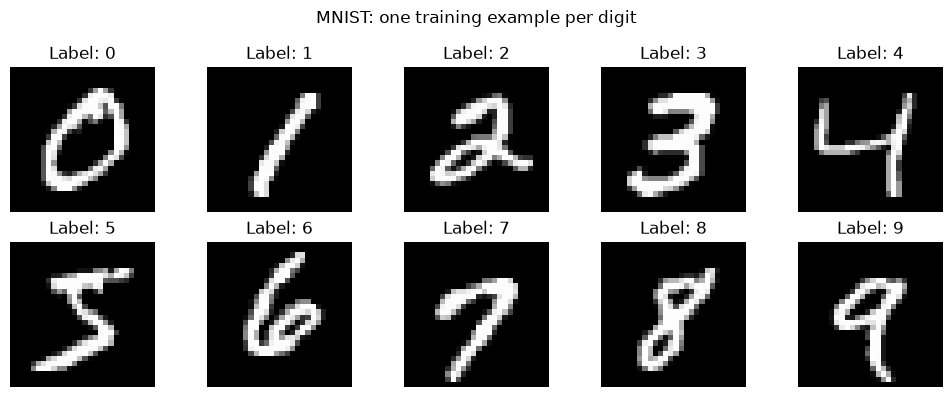

In [3]:
# Show one training image for each digit.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = (mnist_train_full.targets == digit).nonzero(as_tuple=True)[0][0].item()
    image, label = mnist_train_full[index]
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
fig.suptitle("MNIST: one training example per digit")
plt.tight_layout()
plt.show()

### Next step

Split the training pool into training and validation sets, then use `DataLoader` objects to serve batches of images to the model.

## Problem 2: improve flower classification

Adapted from `2_pytorch_CNN_Classify_flowers.ipynb`.

The task is to classify photos as daisy, dandelion, roses, sunflowers or tulips. The course model has three convolutional blocks and two linear layers. We must add two convolutional blocks and one linear layer with ReLU, then document a small set of experiments. We will use no data augmentation.

The supplied notebook records 75.1% training accuracy at its final epoch and 65.34% test accuracy for the checkpoint selected by validation loss. These are different measures; the supplied results are reference results, not results from our own run.

We will keep the same data split across experiments, use validation results to choose settings and check for overfitting, and reserve the test set for final evaluation. Adding depth does not guarantee better accuracy.

**Progress:** load and inspect the photos. The baseline run and model changes will follow.

### 2.1 Load the flower photos

Unlike MNIST, these photos arrive in folders, one per flower class. `ImageFolder` reads the folder names and assigns integer labels in alphabetical order.

`Resize` makes every image 64 x 64 pixels; this can change its proportions. `ToTensor` converts it to a tensor and scales the pixel values to 0-1. `Compose` applies these operations in order. RGB photos have three channels, so each tensor has shape `(3, 64, 64)`.

The first run downloads an archive of about 220 MB into `data/`. Git ignores this folder. We will split this catalogue into training, validation and test sets in the next step.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive

# Separate names keep the flower data distinct from Problem 1's MNIST data.
FLOWER_DATA_DIR = Path("data")
FLOWER_IMAGE_SIZE = 64
flower_root = FLOWER_DATA_DIR / "flower_photos"

# Reuse the downloaded photos on later runs.
if not flower_root.exists():
    download_and_extract_archive(
        "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
        download_root=str(FLOWER_DATA_DIR),
        md5="6f87fb78e9cc9ab41eff2015b380011d",
    )

# Resize to a common size and convert to tensors. No data augmentation.
flower_transform = transforms.Compose([
    transforms.Resize((FLOWER_IMAGE_SIZE, FLOWER_IMAGE_SIZE)),
    transforms.ToTensor(),
])
flower_catalog = datasets.ImageFolder(flower_root, transform=flower_transform)
flower_class_names = flower_catalog.classes
print(f"Images: {len(flower_catalog):,}")
print(f"Folder-to-label mapping: {flower_catalog.class_to_idx}")
flower_image, flower_label = flower_catalog[0]
print(f"One image: {tuple(flower_image.shape)}")
print(f"Label: {flower_label} ({flower_class_names[flower_label]})")

Images: 3,670
Folder-to-label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
One image: (3, 64, 64)
Label: 0 (daisy)


### 2.2 Inspect one photo per class

For MNIST, we removed the single channel dimension to plot a greyscale image. Here, all three colour channels are needed. `permute(1, 2, 0)` moves the channel dimension to the end, changing `(3, 64, 64)` into `(64, 64, 3)` for Matplotlib. It does not discard colour information.

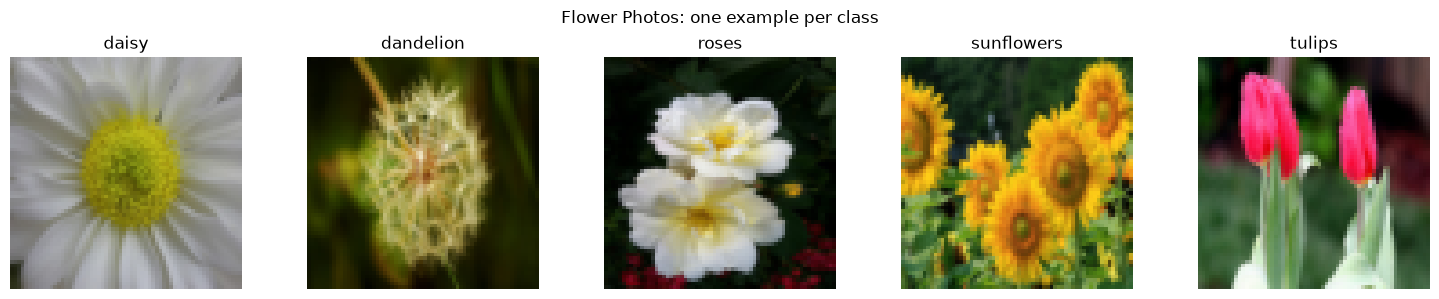

In [2]:
# Show one example per class to check the images and folder labels.
fig, axes = plt.subplots(1, len(flower_class_names), figsize=(15, 3))
for label, ax in enumerate(axes):
    index = flower_catalog.targets.index(label)
    image, target = flower_catalog[index]
    # RGB plotting needs (height, width, channels), rather than (channels, height, width).
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(flower_class_names[target])
    ax.axis("off")
fig.suptitle("Flower Photos: one example per class")
plt.tight_layout()
plt.show()